In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.stats.multicomp as multicomp
import statsmodels.stats.multitest as multitest
import seaborn as sns
import matplotlib.pyplot as plt

# Statistical Analysis: Primary Care Shortage & Health Outcomes

## Supplementary inferential testing to support correlation and group comparison findings
### Dataset: 3,144 US counties | Source: CDC PLACES, HRSA, USDA, County Health Rankings

## 0. Setup & Data Loading

county_health = pd.read_csv("../data-processed/county_health_profile.csv")
access_impact = pd.read_csv("../data-processed/access_impact_analysis.csv")
priority_counties = pd.read_csv("../data-processed/priority_counties_ranking.csv")
regional_patterns = pd.read_csv("../data-processed/regional_patterns.csv")

print("county_health:", len(county_health), "rows")
print("access_impact:", len(access_impact), "rows")
print("priority_counties:", len(priority_counties), "rows")
print("regional_patterns:", len(regional_patterns), "rows")

print(f"county_health: {county_health.shape}")
print(f"access_impact: {access_impact.shape}")
print(f"priority_counties: {priority_counties.shape}")
print(f"regional_patterns: {regional_patterns.shape}")

county_health: 3144 rows
access_impact: 3144 rows
priority_counties: 2914 rows
regional_patterns: 51 rows
county_health: (3144, 83)
access_impact: (3144, 52)
priority_counties: (2914, 51)
regional_patterns: (51, 12)


In [2]:
# 1. Data Quality Verification
# Upstream dbt cleaning handled null removal, negative value conversion, and
# type casting. This section verifies mart outputs before proceeding with analysis.

# Null counts across all four marts
print("\n=== COUNTY HEALTH PROFILE | Null Counts ===")
missing_values_county_health = county_health.isnull().sum().sort_values(ascending=False)
print(missing_values_county_health)
print("\n=== ACCESS IMPACT | Null Counts ===")
missing_values_access_impact = access_impact.isnull().sum().sort_values(ascending=False)
print(missing_values_access_impact)
print("\n=== PRIORITY COUNTIES | Null Counts ===")
missing_values_priority_counties = priority_counties.isnull().sum().sort_values(ascending=False)
print(missing_values_priority_counties)
print("\n=== REGIONAL PATTERNS | Null Counts ===")
missing_values_regional_patterns = regional_patterns.isnull().sum().sort_values(ascending=False)
print(missing_values_regional_patterns)

# Data type verification across all four marts
print("\n=== COUNTY HEALTH PROFILE | Data Types ===")
print(county_health.dtypes)
print("\n=== ACCESS IMPACT | Data Types ===")
print(access_impact.dtypes)
print("\n=== PRIORITY COUNTIES | Data Types ===")
print(priority_counties.dtypes)
print("\n=== REGIONAL PATTERNS | Data Types ===")
print(regional_patterns.dtypes)

# Check disease burden coverage by state
insufficient_data = county_health[county_health['DISEASE_BURDEN_LEVEL'] == 'Insufficient Data']
print(f"Counties with Insufficient Data: {len(insufficient_data)}")
print(insufficient_data['STATE_ABBR'].value_counts())


=== COUNTY HEALTH PROFILE | Null Counts ===
PREVENTABLE_STAYS_AIAN        2867
PREVENTABLE_STAYS_ASIAN       2768
MUAP_DESIGNATED_POPULATION    2389
HISPANIC_WHITE_HOSP_GAP       2380
PREVENTABLE_STAYS_HISPANIC    2371
                              ... 
HPSA_SEVERITY_TIER               0
MUAP_SEVERITY_TIER               0
IS_DUAL_DESIGNATED               0
HAS_FQHC                         0
COUNTY_FIPS                      0
Length: 83, dtype: int64

=== ACCESS IMPACT | Null Counts ===
HISPANIC_WHITE_HOSP_GAP         2380
HAS_RACIAL_DISPARITY            1863
BLACK_WHITE_HOSP_GAP            1863
HPSA_SCORE                       378
POP_PER_PCP                      241
DIABETES_PCT                     188
ARTHRITIS_PCT                    188
STROKE_PCT                       188
DEPRESSION_PCT                   188
COPD_PCT                         188
OBESITY_PCT                      188
HEART_DISEASE_PCT                188
HYPERTENSION_PCT                 188
ASTHMA_PCT                 

county health columns: ['COUNTY_FIPS', 'COUNTY_NAME', 'STATE_NAME', 'STATE_ABBR', 'TOTAL_POPULATION', 'PCT_65_OLDER', 'MEDIAN_HOUSEHOLD_INCOME', 'CHILDREN_IN_POVERTY_PCT', 'INCOME_INEQUALITY_RATIO', 'UNEMPLOYMENT_PCT', 'UNINSURED_PCT', 'UNINSURED_ADULTS_PCT', 'UNINSURED_CHILDREN_PCT', 'PCT_BLACK', 'PCT_HISPANIC', 'PCT_ASIAN', 'PCT_WHITE', 'PCT_RURAL', 'UNINSURED_SUPPRESSED', 'DIABETES_PCT', 'HYPERTENSION_PCT', 'HEART_DISEASE_PCT', 'COPD_PCT', 'ASTHMA_PCT', 'OBESITY_PCT', 'DEPRESSION_PCT', 'STROKE_PCT', 'HIGH_CHOLESTEROL_PCT', 'CANCER_PCT', 'ARTHRITIS_PCT', 'FAIR_POOR_HEALTH_PCT', 'NO_PHYSICAL_ACTIVITY_PCT', 'FOOD_INSECURITY_PCT', 'NO_TRANSPORT_PCT', 'DISEASE_COUNT', 'HAS_MULTIMORBIDITY', 'DISEASE_BURDEN_LEVEL', 'PCP_PER_100K', 'OTHER_PCP_PER_100K', 'POP_PER_PCP', 'POP_PER_OTHER_PCP', 'POP_PER_MENTAL_HEALTH', 'POP_PER_DENTIST', 'PCP_DATA_SUPPRESSED', 'IS_HPSA_DESIGNATED', 'HPSA_SCORE', 'HPSA_SHORTAGE', 'HPSA_FTE_TOTAL', 'HPSA_DESIGNATED_POPULATION', 'HPSA_UNDERSERVED_POPULATION', 'HPSA_

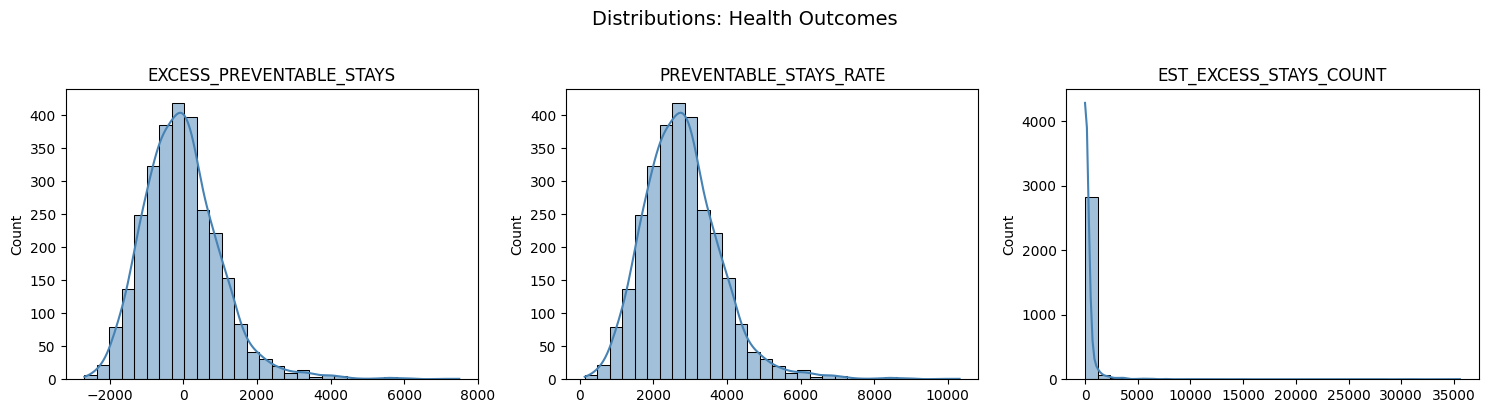

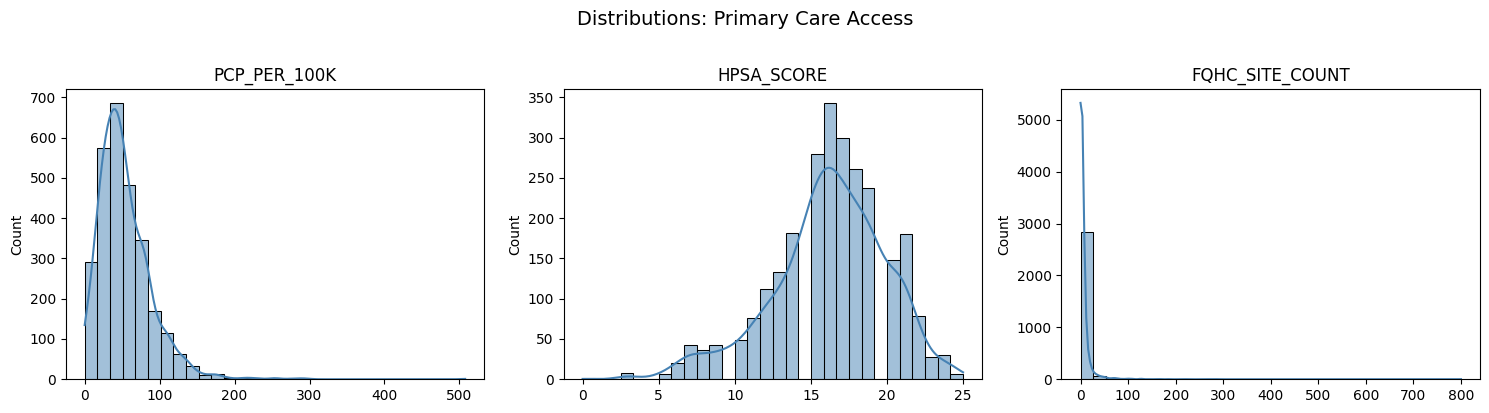

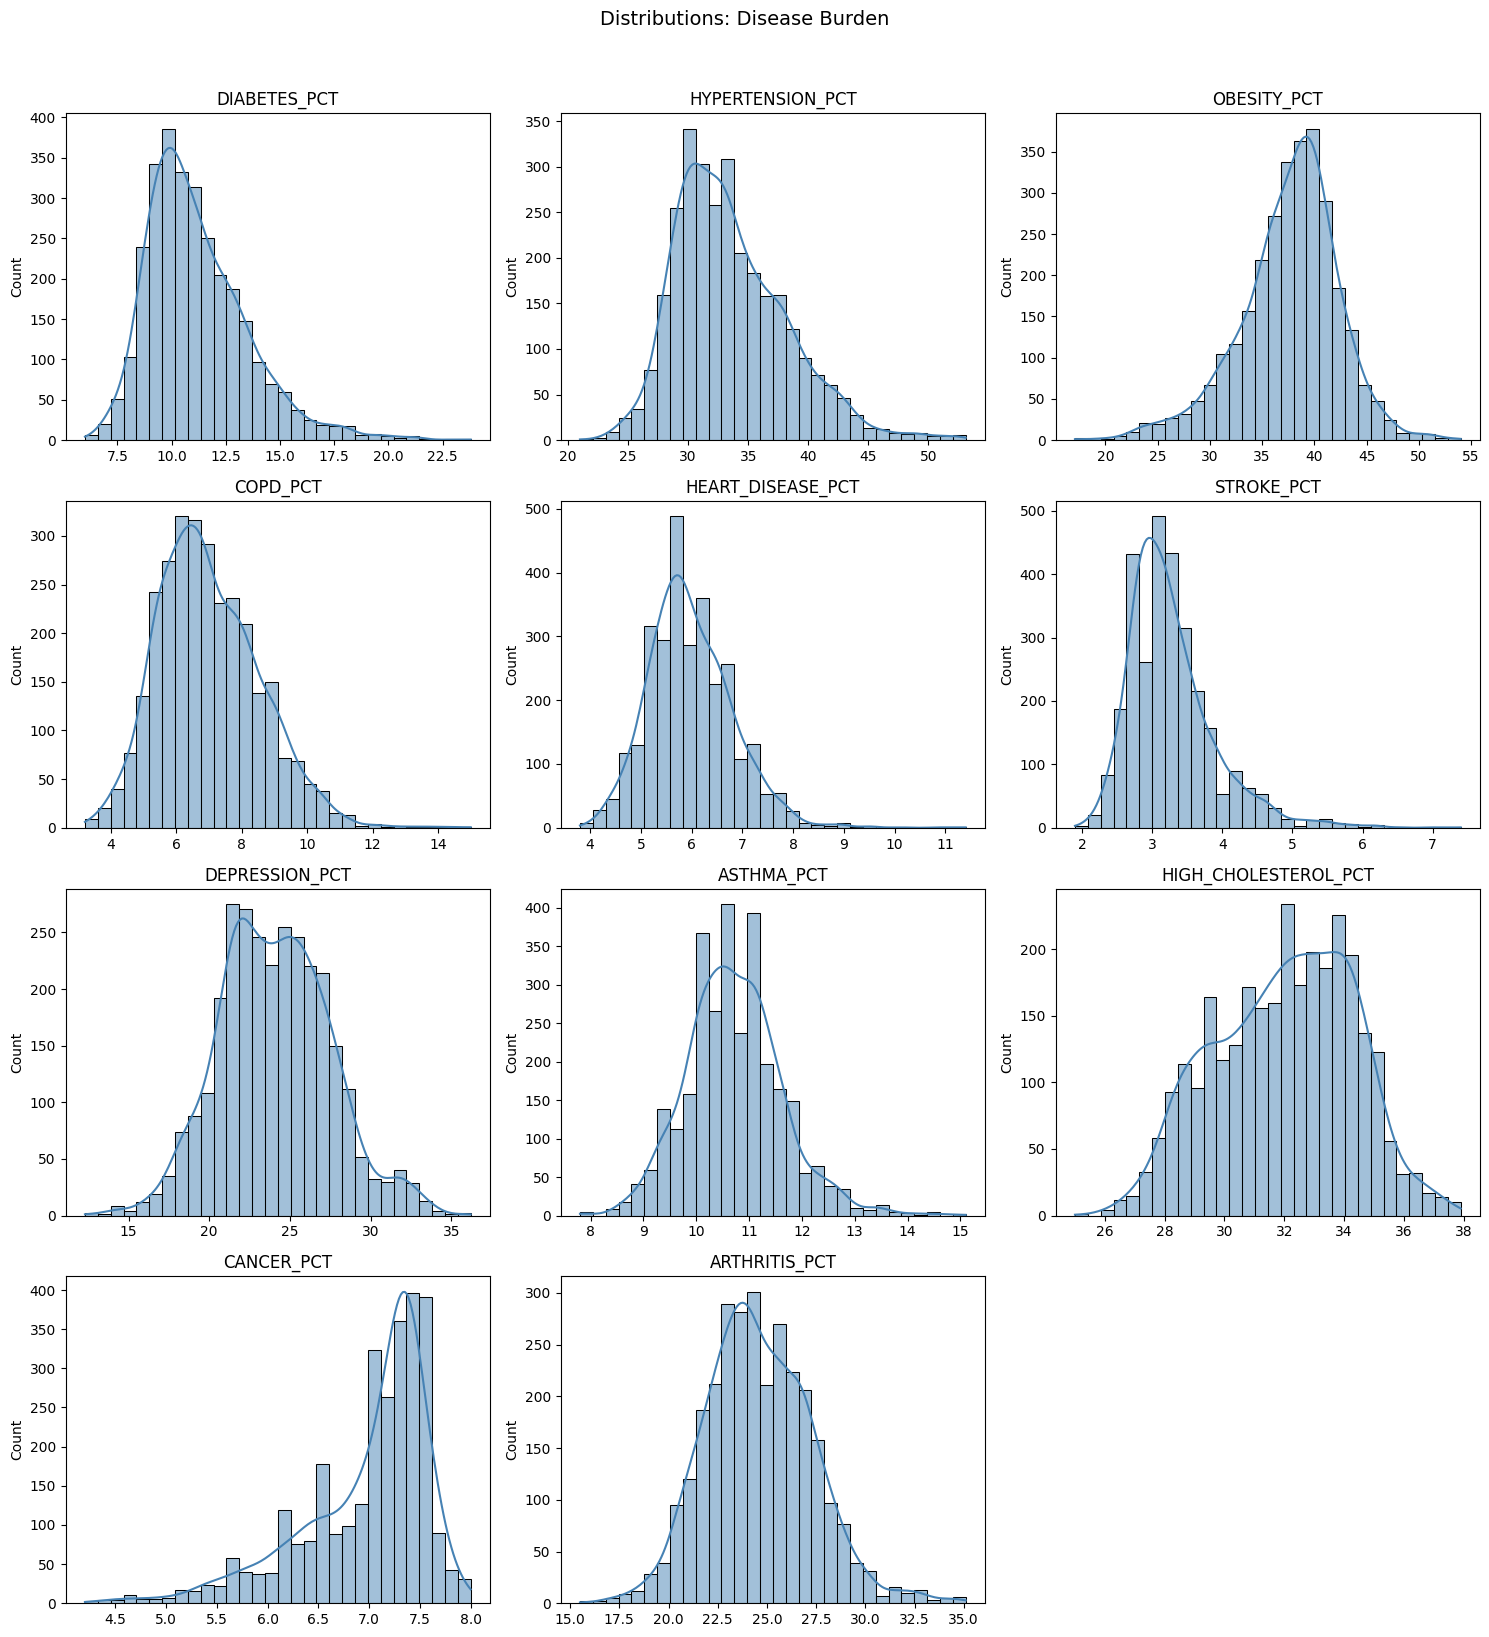

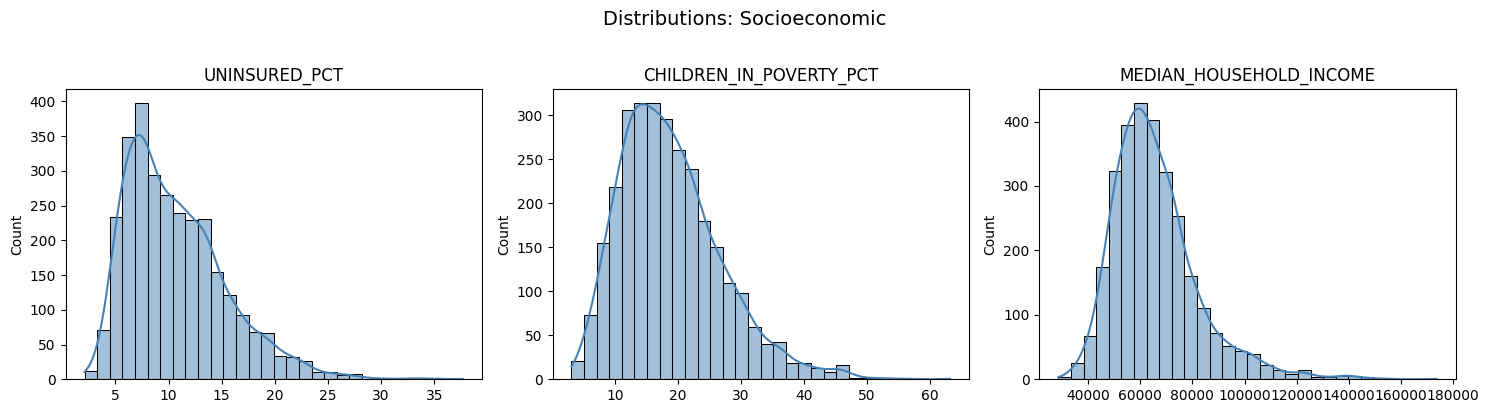


=== BOX PLOTS: HEAVILY SKEWED VARIABLES BY HPSA SEVERITY TIER ===


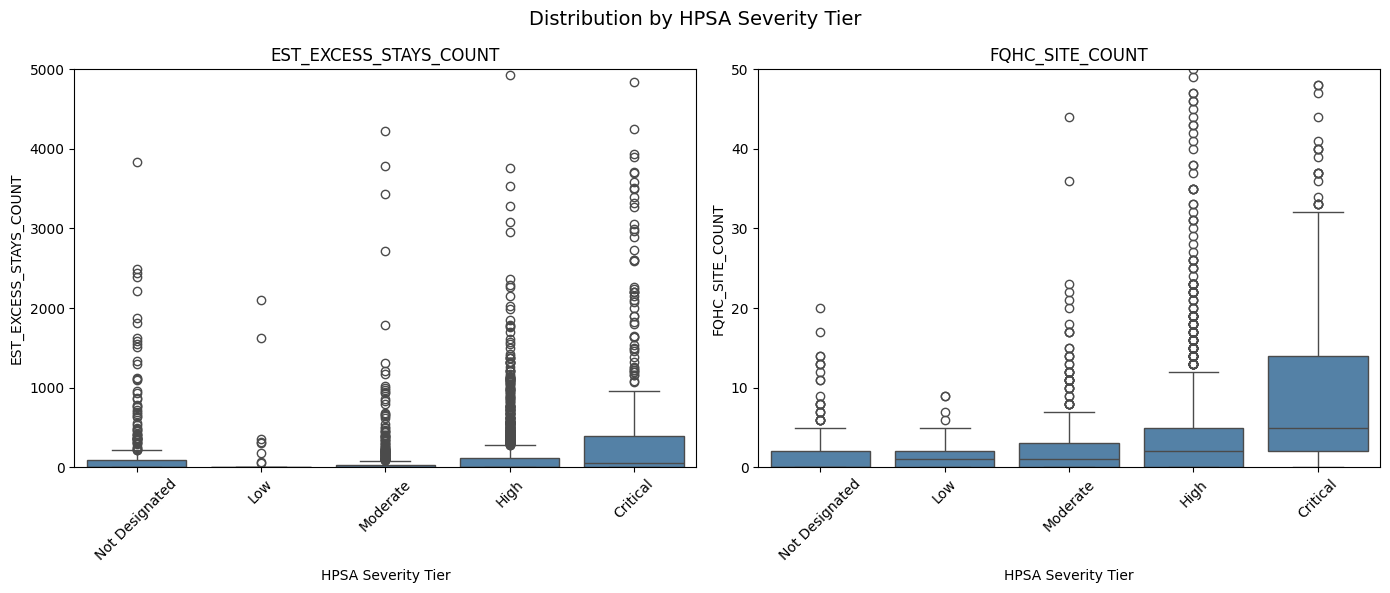

In [ ]:
## 2. Summary Statistics & Distribution

# Checking distributions of key analytical variables before selecting appropriate 
# statistical tests. Skewness values inform whether parametric or non-parametric 
# tests are appropriate.

# Obtain all columns in county health dataset 

# print("county health columns:", county_health.columns.tolist())
# print("access impact columns:", access_impact.columns.tolist())
# print("priority counties columns:", priority_counties.columns.tolist())
# print("regional patterns columns:", regional_patterns.columns.tolist())

# County Health
# Demographics & Socioeconomic
demo_county = ['TOTAL_POPULATION', 'PCT_65_OLDER', 'MEDIAN_HOUSEHOLD_INCOME', 
             'CHILDREN_IN_POVERTY_PCT', 'INCOME_INEQUALITY_RATIO', 
             'UNEMPLOYMENT_PCT', 'UNINSURED_PCT', 'PCT_RURAL']

# Disease Burden
disease_county = ['DIABETES_PCT', 'HYPERTENSION_PCT', 'HEART_DISEASE_PCT', 
                'OBESITY_PCT', 'DEPRESSION_PCT', 'FAIR_POOR_HEALTH_PCT',
                'DISEASE_COUNT']

# Primary Care Access
access_county = ['PCP_PER_100K', 'POP_PER_PCP', 'HPSA_SCORE', 'HPSA_SHORTAGE',
               'HPSA_AVG_PCT_POVERTY', 'IMU_SCORE_AVG', 'FQHC_SITE_COUNT']

# Health Outcomes
outcome_county = ['PREVENTABLE_STAYS_RATE', 'EXCESS_PREVENTABLE_STAYS',
                'LIFE_EXPECTANCY', 'PREMATURE_AGE_ADJ_MORTALITY',
                'INFANT_MORTALITY_RATE', 'EST_EXCESS_STAYS_COUNT',
                'BLACK_WHITE_HOSP_GAP', 'HISPANIC_WHITE_HOSP_GAP']

# Print each group
for name, vars in [('Demographics & Socioeconomic', demo_county),
                   ('Disease Burden', disease_county),
                   ('Primary Care Access', access_county),
                   ('Health Outcomes', outcome_county)]:
    
    print(f"\n=== COUNTY HEALTH | {name} ===")
    print(county_health[vars].describe().round(2))

# Access Impact 
# Demographics & Socioeconomic
demo_impact = ['TOTAL_POPULATION', 'MEDIAN_HOUSEHOLD_INCOME', 
             'CHILDREN_IN_POVERTY_PCT', 'UNINSURED_PCT', 'PCT_RURAL']

# Disease Burden
disease_impact = ['DIABETES_PCT', 'HYPERTENSION_PCT', 'HEART_DISEASE_PCT', 
                'COPD_PCT', 'OBESITY_PCT', 'DISEASE_COUNT', 'DISEASE_BURDEN_LEVEL']

# Primary Care Access
provider_impact = ['PCP_PER_100K', 'POP_PER_PCP', 'HPSA_SCORE', 
               'FQHC_SITE_COUNT', 'IS_HPSA_DESIGNATED', 'IS_MEDICALLY_UNDERSERVED',
               'IS_DUAL_DESIGNATED', 'SHORTAGE_GROUP', 'FQHC_ACCESS_GROUP']

# Health Outcomes
outcome_impact = ['PREVENTABLE_STAYS_RATE', 'EXCESS_PREVENTABLE_STAYS',
                'EST_EXCESS_STAYS_COUNT', 'ABOVE_NATIONAL_AVG_HOSP',
                'LIFE_EXPECTANCY', 'PREMATURE_AGE_ADJ_MORTALITY',
                'BLACK_WHITE_HOSP_GAP', 'HISPANIC_WHITE_HOSP_GAP']

# Print each group
for name, vars in [('Demographics & Socioeconomic', demo_impact),
                   ('Disease Burden', disease_impact),
                   ('Primary Care Access', provider_impact),
                   ('Health Outcomes', outcome_impact)]:
   
    print(f"\n=== ACCESS IMPACT | {name} ===")
    print(access_impact[vars].describe().round(2))

    # Categorical columns
cat_cols = ['DISEASE_BURDEN_LEVEL', 'SHORTAGE_GROUP', 'FQHC_ACCESS_GROUP']
print("\n=== ACCESS IMPACT | Categorical Variables ===")
print(access_impact[cat_cols].describe())

# Priority Counties 
# Demographics & Socioeconomic
demo_priority = ['TOTAL_POPULATION', 'MEDIAN_HOUSEHOLD_INCOME', 
                 'CHILDREN_IN_POVERTY_PCT', 'UNINSURED_PCT', 'PCT_RURAL']

disease_priority = ['DIABETES_PCT', 'HYPERTENSION_PCT', 'HEART_DISEASE_PCT', 
                    'OBESITY_PCT', 'DISEASE_COUNT', 'DISEASE_BURDEN_LEVEL']

provider_priority = ['PCP_PER_100K', 'POP_PER_PCP', 'HPSA_SCORE',
                     'IS_HPSA_DESIGNATED', 'IS_MEDICALLY_UNDERSERVED',
                     'IS_DUAL_DESIGNATED', 'HAS_FQHC', 'VULNERABILITY_SCORE',
                     'PRIORITY_SCORE', 'SHORTAGE_SCORE']

outcome_priority = ['PREVENTABLE_STAYS_RATE', 'EXCESS_PREVENTABLE_STAYS',
                    'ABOVE_NATIONAL_AVG_HOSP', 'LIFE_EXPECTANCY',
                    'BLACK_WHITE_HOSP_GAP', 'HISPANIC_WHITE_HOSP_GAP',
                    'ADMISSIONS_PREVENTABLE', 'DISEASE_SCORE', 'OUTCOME_SCORE']

# Print each group 
for name, vars in [('Demographics & Socioeconomic', demo_priority),
                   ('Disease Burden', disease_priority),
                   ('Primary Care Access', provider_priority),
                   ('Health Outcomes', outcome_priority)]:
    print(f"\n=== PRIORITY COUNTIES | {name} ===")
    print(priority_counties[vars].describe().round(2))

# Rgional Patterns 
demo_regional = ['TOTAL_COUNTIES', 'AVG_UNINSURED_PCT', 'AVG_POVERTY_PCT']

disease_regional = ['HIGH_BURDEN_COUNTIES']

provider_regional = ['HPSA_COUNTIES', 'MUAP_COUNTIES', 'DUAL_DESIGNATED_COUNTIES',
                     'AVG_PCP_PER_100K', 'AVG_PRIORITY_SCORE']

outcome_regional = ['AVG_EXCESS_STAYS']

# Print each group 
for name, vars in [('Demographics & Socioeconomic', demo_regional),
                   ('Disease Burden', disease_regional),
                   ('Primary Care Access', provider_regional),
                   ('Health Outcomes', outcome_regional)]:
    print(f"\n=== REGIONAL PATTERNS | {name} ===")
    print(regional_patterns[vars].describe().round(2))

# Variables with |skew| > 1 are considered highly skewed
# and may require non-parametric tests or log transformation

print("=== Demographics & Socioeconomic Skewness ===")
print(county_health[demo_county].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Disease Burden Skewness ===")
print(county_health[disease_county].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Primary Care Access Skewness ===")
print(county_health[access_county].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Health Outcomes Skewness ===")
print(county_health[outcome_county].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("=== Demographics & Socioeconomic Skewness ===")
print(access_impact[demo_impact].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Disease Burden Skewness ===")
print(access_impact[disease_impact].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Primary Care Access Skewness ===")
print(access_impact[provider_impact].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Health Outcomes Skewness ===")
print(access_impact[outcome_impact].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("=== Demographics & Socioeconomic Skewness ===")
print(priority_counties[demo_priority].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Disease Burden Skewness ===")
print(priority_counties[disease_priority].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Primary Care Access Skewness ===")
print(priority_counties[provider_priority].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Health Outcomes Skewness ===")
print(priority_counties[outcome_priority].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("=== Demographics & Socioeconomic Skewness ===")
print(regional_patterns[demo_regional].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Disease Burden Skewness ===")
print(regional_patterns[disease_regional].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Primary Care Access Skewness ===")
print(regional_patterns[provider_regional].skew(numeric_only=True).sort_values(ascending=False).round(2))

print("\n=== Health Outcomes Skewness ===")
print(regional_patterns[outcome_regional].skew(numeric_only=True).sort_values(ascending=False).round(2))

## IQR Analysis: HPSA Designated vs Not Designated

iqr_vars = [
    'DIABETES_PCT',
    'HYPERTENSION_PCT',
    'HEART_DISEASE_PCT',
    'COPD_PCT',
    'OBESITY_PCT',
    'DEPRESSION_PCT',
    'STROKE_PCT',
    'ASTHMA_PCT',
    'HIGH_CHOLESTEROL_PCT',
    'CANCER_PCT',
    'ARTHRITIS_PCT'
]

print(f"\n=== IQR ANALYSIS: HPSA DESIGNATED vs NOT DESIGNATED ===")

for var in iqr_vars:
    print(f"\n--- {var} ---")
    print(county_health.groupby('IS_HPSA_DESIGNATED')[var].describe(
        percentiles=[.25, .50, .75]).round(2)[['count', '25%', '50%', '75%', 'mean']])

print(f"\n=== IQR ANALYSIS: BY HPSA SEVERITY TIER ===")

print(county_health['HPSA_SEVERITY_TIER'].value_counts())

tier_order = ['Not Designated', 'Low', 'Moderate', 'High', 'Critical']

for var in iqr_vars:
    print(f"\n--- {var} ---")
    result = county_health.groupby('HPSA_SEVERITY_TIER')[var].describe(
        percentiles=[.25, .50, .75]).round(2)[['count', '25%', '50%', '75%', 'mean']]
    print(result.reindex(tier_order))

print(f"\n=== IQR ANALYSIS: FQHC PRESENCE vs EXCESS PREVENTABLE STAYS ===")

fqhc_vars = ['EXCESS_PREVENTABLE_STAYS', 'EST_EXCESS_STAYS_COUNT']

for var in fqhc_vars:
    print(f"\n--- {var} ---")
    print(county_health.groupby('HAS_FQHC')[var].describe(
        percentiles=[.25, .50, .75]).round(2)[['count', '25%', '50%', '75%', 'mean']])

print(f"\n=== IQR ANALYSIS: BY FQHC ACCESS GROUP ===")

for var in fqhc_vars:
    print(f"\n--- {var} ---")
    print(access_impact.groupby('FQHC_ACCESS_GROUP')[var].describe(
        percentiles=[.25, .50, .75]).round(2)[['count', '25%', '50%', '75%', 'mean']])

dist_vars = {
    'Health Outcomes': [
        'EXCESS_PREVENTABLE_STAYS',
        'PREVENTABLE_STAYS_RATE',
        'EST_EXCESS_STAYS_COUNT'
    ],
    'Primary Care Access': [
        'PCP_PER_100K',
        'HPSA_SCORE',
        'FQHC_SITE_COUNT'
    ],
    'Disease Burden': [
        'DIABETES_PCT',
        'HYPERTENSION_PCT',
        'OBESITY_PCT',
        'COPD_PCT',
        'HEART_DISEASE_PCT',
        'STROKE_PCT',
        'DEPRESSION_PCT',
        'ASTHMA_PCT',
        'HIGH_CHOLESTEROL_PCT',
        'CANCER_PCT',
        'ARTHRITIS_PCT'
    ],
    'Socioeconomic': [
        'UNINSURED_PCT',
        'CHILDREN_IN_POVERTY_PCT',
        'MEDIAN_HOUSEHOLD_INCOME'
    ]
}

print(f"\n=== HISTOGRAMS CONTINUOUS VARIABLES ===")

for group_name, vars in dist_vars.items():
    n_vars = len(vars)
    n_cols = 3
    n_rows = (n_vars + n_cols - 1) // n_cols  # ceiling division
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    fig.suptitle(f'Distributions: {group_name}', fontsize=14, y=1.02)
    axes = axes.flatten()
    
    for i, var in enumerate(vars):
        sns.histplot(
            data=county_health[var].dropna(),
            ax=axes[i],
            bins=30,
            kde=True,          # adds smoothed density curve
            color='steelblue'
        )
        axes[i].set_title(var)
        axes[i].set_xlabel('')
    
    # hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

print(f"\n=== BOX PLOTS: HEAVILY SKEWED VARIABLES BY HPSA SEVERITY TIER ===")

boxplot_vars = ['EST_EXCESS_STAYS_COUNT', 'FQHC_SITE_COUNT']

tier_order = ['Not Designated', 'Low', 'Moderate', 'High', 'Critical']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribution by HPSA Severity Tier', fontsize=14)

for i, var in enumerate(boxplot_vars):
    sns.boxplot(
        data=county_health,
        x='HPSA_SEVERITY_TIER',
        y=var,
        order=tier_order,
        ax=axes[i],
        color='steelblue'
    )
    axes[i].set_title(var)
    axes[i].set_xlabel('HPSA Severity Tier')
    axes[i].tick_params(axis='x', rotation=45)

axes[0].set_ylim(0, 5000)   # EST_EXCESS_STAYS_COUNT
axes[1].set_ylim(0, 50)     # FQHC_SITE_COUNT

plt.tight_layout()
plt.show()


In [9]:

## 3. P-values for Correlations

# Testing statistical significance of Pearson and Spearman correlations reported in the main 
# analysis.

print(f"\n=== CORRELATIONS AND P-VALUES ===")

# Statistical Significance of Pearson Correlations

# HPSA_SCORE vs EXCESS_PREVENTABLE_STAYS
print("\n=== HPSA SCORE vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['HPSA_SCORE', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.pearsonr(subset['HPSA_SCORE'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# PCP_PER_100K vs EXCESS_PREVENTABLE_STAYS
print("\n=== PCP PER 100K vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['PCP_PER_100K', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.pearsonr(subset['PCP_PER_100K'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# UNINSURED_PCT vs EXCESS_PREVENTABLE_STAYS
print("\n=== UNINSURED PCT vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['UNINSURED_PCT', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.pearsonr(subset['UNINSURED_PCT'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# CHILDREN_IN_POVERTY_PCT vs EXCESS_PREVENTABLE_STAYS
print("\n=== CHILDREN IN POVERTY vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['CHILDREN_IN_POVERTY_PCT', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.pearsonr(subset['CHILDREN_IN_POVERTY_PCT'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# BLACK_WHITE_HOSP_GAP vs EXCESS_PREVENTABLE_STAYS
print("\n=== BLACK WHITE HOSP GAP vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['BLACK_WHITE_HOSP_GAP', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.pearsonr(subset['BLACK_WHITE_HOSP_GAP'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HISPANIC_WHITE_HOSP_GAP vs EXCESS_PREVENTABLE_STAYS
print("\n=== HISPANIC WHITE HOSP GAP vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['HISPANIC_WHITE_HOSP_GAP', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.pearsonr(subset['HISPANIC_WHITE_HOSP_GAP'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# IMU_SCORE_WORST vs EXCESS_PREVENTABLE_STAYS
print("\n=== IMU SCORE WORST vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['IMU_SCORE_WORST', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.pearsonr(subset['IMU_SCORE_WORST'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HPSA_SCORE vs DIABETES_PCT
print("\n=== HPSA SCORE vs DIABETES PCT ===")
subset = county_health[['HPSA_SCORE', 'DIABETES_PCT']].dropna()
r, p = stats.pearsonr(subset['HPSA_SCORE'], subset['DIABETES_PCT'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HPSA_SCORE vs OBESITY_PCT
print("\n=== HPSA SCORE vs OBESITY PCT ===")
subset = county_health[['HPSA_SCORE', 'OBESITY_PCT']].dropna()
r, p = stats.pearsonr(subset['HPSA_SCORE'], subset['OBESITY_PCT'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HPSA_SCORE vs HYPERTENSION_PCT
print("\n=== HPSA SCORE vs HYPERTENSION PCT ===")
subset = county_health[['HPSA_SCORE', 'HYPERTENSION_PCT']].dropna()
r, p = stats.pearsonr(subset['HPSA_SCORE'], subset['HYPERTENSION_PCT'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# Statistical Significance of Spearman Correlations

# HPSA_SCORE vs EXCESS_PREVENTABLE_STAYS
print("\n=== HPSA SCORE vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['HPSA_SCORE', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.spearmanr(subset['HPSA_SCORE'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# PCP_PER_100K vs EXCESS_PREVENTABLE_STAYS
print("\n=== PCP PER 100K vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['PCP_PER_100K', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.spearmanr(subset['PCP_PER_100K'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# UNINSURED_PCT vs EXCESS_PREVENTABLE_STAYS
print("\n=== UNINSURED PCT vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['UNINSURED_PCT', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.spearmanr(subset['UNINSURED_PCT'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}") 

# CHILDREN_IN_POVERTY_PCT vs EXCESS_PREVENTABLE_STAYS
print("\n=== CHILDREN IN POVERTY vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['CHILDREN_IN_POVERTY_PCT', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.spearmanr(subset['CHILDREN_IN_POVERTY_PCT'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# BLACK_WHITE_HOSP_GAP vs EXCESS_PREVENTABLE_STAYS
print("\n=== BLACK WHITE HOSP GAP vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['BLACK_WHITE_HOSP_GAP', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.spearmanr(subset['BLACK_WHITE_HOSP_GAP'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HISPANIC_WHITE_HOSP_GAP vs EXCESS_PREVENTABLE_STAYS
print("\n=== HISPANIC WHITE HOSP GAP vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['HISPANIC_WHITE_HOSP_GAP', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.spearmanr(subset['HISPANIC_WHITE_HOSP_GAP'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# IMU_SCORE_WORST vs EXCESS_PREVENTABLE_STAYS
print("\n=== IMU SCORE WORST vs EXCESS PREVENTABLE STAYS ===")
subset = county_health[['IMU_SCORE_WORST', 'EXCESS_PREVENTABLE_STAYS']].dropna()
r, p = stats.spearmanr(subset['IMU_SCORE_WORST'], subset['EXCESS_PREVENTABLE_STAYS'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HPSA_SCORE vs DIABETES_PCT
print("\n=== HPSA SCORE vs DIABETES PCT ===")
subset = county_health[['HPSA_SCORE', 'DIABETES_PCT']].dropna()
r, p = stats.spearmanr(subset['HPSA_SCORE'], subset['DIABETES_PCT'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HPSA_SCORE vs HYPERTENSION_PCT
print("\n=== HPSA SCORE vs HYPERTENSION PCT ===")
subset = county_health[['HPSA_SCORE', 'HYPERTENSION_PCT']].dropna()
r, p = stats.spearmanr(subset['HPSA_SCORE'], subset['HYPERTENSION_PCT'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")

# HPSA_SCORE vs OBESITY_PCT
print("\n=== HPSA SCORE vs OBESITY PCT ===")
subset = county_health[['HPSA_SCORE', 'OBESITY_PCT']].dropna()
r, p = stats.spearmanr(subset['HPSA_SCORE'], subset['OBESITY_PCT'])
print(f"r = {r:.2f}, p = {p:.4f}, n = {len(subset)}")


=== CORRELATIONS AND P-VALUES ===

=== HPSA SCORE vs EXCESS PREVENTABLE STAYS ===
r = 0.18, p = 0.0000, n = 2521

=== PCP PER 100K vs EXCESS PREVENTABLE STAYS ===
r = -0.15, p = 0.0000, n = 2737

=== UNINSURED PCT vs EXCESS PREVENTABLE STAYS ===
r = 0.15, p = 0.0000, n = 2874

=== CHILDREN IN POVERTY vs EXCESS PREVENTABLE STAYS ===
r = 0.33, p = 0.0000, n = 2874

=== BLACK WHITE HOSP GAP vs EXCESS PREVENTABLE STAYS ===
r = -0.01, p = 0.6084, n = 1217

=== HISPANIC WHITE HOSP GAP vs EXCESS PREVENTABLE STAYS ===
r = 0.05, p = 0.1695, n = 736

=== IMU SCORE WORST vs EXCESS PREVENTABLE STAYS ===
r = 0.03, p = 0.1113, n = 2258

=== HPSA SCORE vs DIABETES PCT ===
r = 0.39, p = 0.0000, n = 2598

=== HPSA SCORE vs OBESITY PCT ===
r = 0.15, p = 0.0000, n = 2598

=== HPSA SCORE vs HYPERTENSION PCT ===
r = 0.36, p = 0.0000, n = 2598

=== HPSA SCORE vs EXCESS PREVENTABLE STAYS ===
r = 0.18, p = 0.0000, n = 2521

=== PCP PER 100K vs EXCESS PREVENTABLE STAYS ===
r = -0.19, p = 0.0000, n = 2737

===

In [14]:

## 4. T-tests for Group Comparisons

# Formally testing whether differences in chronic disease prevalence between 
# HPSA-designated and non-designated counties are statistically significant.
# Test choice (parametric vs non-parametric) informed by distribution analysis above.
# T-test: FQHC Presence vs Excess Preventable Stays 
# T-Test: Excess Preventable Stays by HPSA Quartile

hpsa = county_health[county_health['IS_HPSA_DESIGNATED'] == 1]
non_hpsa = county_health[county_health['IS_HPSA_DESIGNATED'] == 0]

print(f"\n=== T-TEST: HPSA vs NON-HPSA DISEASE PREVALENCE ===")

# DIABETES_PCT
hpsa_vals = hpsa['DIABETES_PCT'].dropna()
non_hpsa_vals = non_hpsa['DIABETES_PCT'].dropna()
stat, p = stats.ttest_ind(hpsa_vals, non_hpsa_vals, equal_var=False)
print(f"DIABETES_PCT: t = {stat:.3f}, p = {p:.4f}")

# HYPERTENSION_PCT
hpsa_vals = hpsa['HYPERTENSION_PCT'].dropna()
non_hpsa_vals = non_hpsa['HYPERTENSION_PCT'].dropna()
stat, p = stats.ttest_ind(hpsa_vals, non_hpsa_vals, equal_var=False)
print(f"HYPERTENSION_PCT: t = {stat:.3f}, p = {p:.4f}")

# HEART_DISEASE_PCT
hpsa_vals = hpsa['HEART_DISEASE_PCT'].dropna()
non_hpsa_vals = non_hpsa['HEART_DISEASE_PCT'].dropna()
stat, p = stats.ttest_ind(hpsa_vals, non_hpsa_vals, equal_var=False)
print(f"HEART_DISEASE_PCT: t = {stat:.3f}, p = {p:.4f}")

# COPD_PCT
hpsa_vals = hpsa['COPD_PCT'].dropna()
non_hpsa_vals = non_hpsa['COPD_PCT'].dropna()
stat, p = stats.ttest_ind(hpsa_vals, non_hpsa_vals, equal_var=False)
print(f"COPD_PCT: t = {stat:.3f}, p = {p:.4f}")

# OBESITY_PCT
hpsa_vals = hpsa['OBESITY_PCT'].dropna()
non_hpsa_vals = non_hpsa['OBESITY_PCT'].dropna()
stat, p = stats.ttest_ind(hpsa_vals, non_hpsa_vals, equal_var=False)
print(f"OBESITY_PCT: t = {stat:.3f}, p = {p:.4f}")

# DEPRESSION_PCT
hpsa_vals = hpsa['DEPRESSION_PCT'].dropna()
non_hpsa_vals = non_hpsa['DEPRESSION_PCT'].dropna()
stat, p = stats.ttest_ind(hpsa_vals, non_hpsa_vals, equal_var=False)
print(f"DEPRESSION_PCT: t = {stat:.3f}, p = {p:.4f}")

# STROKE_PCT
hpsa_vals = hpsa['STROKE_PCT'].dropna()
non_hpsa_vals = non_hpsa['STROKE_PCT'].dropna()
stat, p = stats.ttest_ind(hpsa_vals, non_hpsa_vals, equal_var=False)
print(f"STROKE_PCT: t = {stat:.3f}, p = {p:.4f}")

# ASTHMA_PCT
hpsa_vals = hpsa['ASTHMA_PCT'].dropna()
non_hpsa_vals = non_hpsa['ASTHMA_PCT'].dropna()
stat, p = stats.ttest_ind(hpsa_vals, non_hpsa_vals, equal_var=False)
print(f"ASTHMA_PCT: t = {stat:.3f}, p = {p:.4f}")

# HIGH_CHOLESTEROL_PCT
hpsa_vals = hpsa['HIGH_CHOLESTEROL_PCT'].dropna()
non_hpsa_vals = non_hpsa['HIGH_CHOLESTEROL_PCT'].dropna()
stat, p = stats.ttest_ind(hpsa_vals, non_hpsa_vals, equal_var=False)
print(f"HIGH_CHOLESTEROL_PCT: t = {stat:.3f}, p = {p:.4f}")

# CANCER_PCT
hpsa_vals = hpsa['CANCER_PCT'].dropna()
non_hpsa_vals = non_hpsa['CANCER_PCT'].dropna()
stat, p = stats.ttest_ind(hpsa_vals, non_hpsa_vals, equal_var=False)
print(f"CANCER_PCT: t = {stat:.3f}, p = {p:.4f}")

# ARTHRITIS_PCT
hpsa_vals = hpsa['ARTHRITIS_PCT'].dropna()
non_hpsa_vals = non_hpsa['ARTHRITIS_PCT'].dropna()
stat, p = stats.ttest_ind(hpsa_vals, non_hpsa_vals, equal_var=False)
print(f"ARTHRITIS_PCT: t = {stat:.3f}, p = {p:.4f}")

# FQHC Presence vs Excess Preventable Stays

fqhc_vals = county_health[county_health['HAS_FQHC'] == 1]['EXCESS_PREVENTABLE_STAYS'].dropna()
no_fqhc_vals = county_health[county_health['HAS_FQHC'] == 0]['EXCESS_PREVENTABLE_STAYS'].dropna()
shortage_fqhc_vals = access_impact[access_impact['FQHC_ACCESS_GROUP'] == 'Shortage + FQHC']['EXCESS_PREVENTABLE_STAYS'].dropna()
shortage_no_fqhc_vals = access_impact[access_impact['FQHC_ACCESS_GROUP'] == 'Shortage, No FQHC']['EXCESS_PREVENTABLE_STAYS'].dropna()

print(f"\n=== T-TEST: FQHC PRESENCE vs EXCESS PREVENTABLE STAYS ===")

# Overall: HAS_FQHC vs No FQHC

stat, p = stats.ttest_ind(fqhc_vals, no_fqhc_vals, equal_var=False)
print(f"Overall FQHC vs No FQHC: t = {stat:.3f}, p = {p:.4f}")

# Within shortage counties: Shortage + FQHC vs Shortage No FQHC
stat, p = stats.ttest_ind(shortage_fqhc_vals, shortage_no_fqhc_vals, equal_var=False)
print(f"Shortage + FQHC vs Shortage No FQHC: t = {stat:.3f}, p = {p:.4f}")

# One-Way ANOVA: Excess Preventable Stays by HPSA Quartile
# NTILE(4) replicated using rank-based qcut with COUNTY_FIPS as tiebreaker
# to ensure consistency with Snowflake SQL results

county_health_hpsa = county_health[['HPSA_SCORE', 'EXCESS_PREVENTABLE_STAYS', 'COUNTY_FIPS']].dropna()
county_health_hpsa = county_health_hpsa.sort_values(['HPSA_SCORE', 'COUNTY_FIPS'])
county_health_hpsa['HPSA_QUARTILE'] = pd.qcut(county_health_hpsa['HPSA_SCORE'].rank(method='first'), q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

print(f"\n=== ANOVA: EXCESS PREVENTABLE STAYS BY HPSA QUARTILE ===")

q1_vals = county_health_hpsa[county_health_hpsa['HPSA_QUARTILE'] == 'Q1']['EXCESS_PREVENTABLE_STAYS']
q2_vals = county_health_hpsa[county_health_hpsa['HPSA_QUARTILE'] == 'Q2']['EXCESS_PREVENTABLE_STAYS']
q3_vals = county_health_hpsa[county_health_hpsa['HPSA_QUARTILE'] == 'Q3']['EXCESS_PREVENTABLE_STAYS']
q4_vals = county_health_hpsa[county_health_hpsa['HPSA_QUARTILE'] == 'Q4']['EXCESS_PREVENTABLE_STAYS']

stat, p = stats.f_oneway(q1_vals, q2_vals, q3_vals, q4_vals)
print(f"ANOVA: F = {stat:.3f}, p = {p:.4f}")

print(f"\nGroup means:")
print(f"Q1: {q1_vals.mean():.2f}")
print(f"Q2: {q2_vals.mean():.2f}")
print(f"Q3: {q3_vals.mean():.2f}")
print(f"Q4: {q4_vals.mean():.2f}")

tukey = multicomp.pairwise_tukeyhsd(
    county_health_hpsa['EXCESS_PREVENTABLE_STAYS'],
    county_health_hpsa['HPSA_QUARTILE']
)
print(tukey)

# Bonferroni correction for multiple t-tests
print(f"\n=== BONFERRONI CORRECTION: HPSA vs NON-HPSA DISEASE PREVALENCE ===")

disease_vars = [
    'DIABETES_PCT', 'HYPERTENSION_PCT', 'HEART_DISEASE_PCT', 'COPD_PCT',
    'OBESITY_PCT', 'DEPRESSION_PCT', 'STROKE_PCT', 'ASTHMA_PCT',
    'HIGH_CHOLESTEROL_PCT', 'CANCER_PCT', 'ARTHRITIS_PCT'
]

p_values = [
    stats.ttest_ind(hpsa[var].dropna(), non_hpsa[var].dropna(), equal_var=False)[1]
    for var in disease_vars
]

reject, p_corrected, _, _ = multitest.multipletests(p_values, method='bonferroni')

print(f"DIABETES_PCT:          p_original = {p_values[0]:.4f}, p_corrected = {p_corrected[0]:.4f}, reject H0 = {reject[0]}")
print(f"HYPERTENSION_PCT:      p_original = {p_values[1]:.4f}, p_corrected = {p_corrected[1]:.4f}, reject H0 = {reject[1]}")
print(f"HEART_DISEASE_PCT:     p_original = {p_values[2]:.4f}, p_corrected = {p_corrected[2]:.4f}, reject H0 = {reject[2]}")
print(f"COPD_PCT:              p_original = {p_values[3]:.4f}, p_corrected = {p_corrected[3]:.4f}, reject H0 = {reject[3]}")
print(f"OBESITY_PCT:           p_original = {p_values[4]:.4f}, p_corrected = {p_corrected[4]:.4f}, reject H0 = {reject[4]}")
print(f"DEPRESSION_PCT:        p_original = {p_values[5]:.4f}, p_corrected = {p_corrected[5]:.4f}, reject H0 = {reject[5]}")
print(f"STROKE_PCT:            p_original = {p_values[6]:.4f}, p_corrected = {p_corrected[6]:.4f}, reject H0 = {reject[6]}")
print(f"ASTHMA_PCT:            p_original = {p_values[7]:.4f}, p_corrected = {p_corrected[7]:.4f}, reject H0 = {reject[7]}")
print(f"HIGH_CHOLESTEROL_PCT:  p_original = {p_values[8]:.4f}, p_corrected = {p_corrected[8]:.4f}, reject H0 = {reject[8]}")
print(f"CANCER_PCT:            p_original = {p_values[9]:.4f}, p_corrected = {p_corrected[9]:.4f}, reject H0 = {reject[9]}")
print(f"ARTHRITIS_PCT:         p_original = {p_values[10]:.4f}, p_corrected = {p_corrected[10]:.4f}, reject H0 = {reject[10]}")


=== T-TEST: HPSA vs NON-HPSA DISEASE PREVALENCE ===
DIABETES_PCT: t = 13.109, p = 0.0000
HYPERTENSION_PCT: t = 10.705, p = 0.0000
HEART_DISEASE_PCT: t = 17.707, p = 0.0000
COPD_PCT: t = 16.000, p = 0.0000
OBESITY_PCT: t = 5.840, p = 0.0000
DEPRESSION_PCT: t = 7.145, p = 0.0000
STROKE_PCT: t = 16.819, p = 0.0000
ASTHMA_PCT: t = 11.397, p = 0.0000
HIGH_CHOLESTEROL_PCT: t = 3.947, p = 0.0001
CANCER_PCT: t = -7.200, p = 0.0000
ARTHRITIS_PCT: t = 11.154, p = 0.0000

=== T-TEST: FQHC PRESENCE vs EXCESS PREVENTABLE STAYS ===
Overall FQHC vs No FQHC: t = 4.568, p = 0.0000
Shortage + FQHC vs Shortage No FQHC: t = 3.883, p = 0.0001

=== ANOVA: EXCESS PREVENTABLE STAYS BY HPSA QUARTILE ===
ANOVA: F = 23.237, p = 0.0000

Group means:
Q1: -225.90
Q2: -87.43
Q3: -9.40
Q4: 260.51
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
    Q1     Q2  138.473 0.0968 -15.8666 292.8127  False
   

In [15]:

## 5. Chi-squared Test

# Tests statistical significance and association between two categorical variables

# Testing associations between categorical shortage/access variables and
# above-average preventable hospitalization rates using contingency tables.

# 5a. Disease Burden Level vs Above National Avg Hospitalization
print("\n=== CHI-SQUARED: DISEASE BURDEN LEVEL vs ABOVE NATIONAL AVG HOSPITALIZATION ===")

subset = access_impact[['DISEASE_BURDEN_LEVEL', 'ABOVE_NATIONAL_AVG_HOSP']].dropna()

# Filter out 'Insufficient Data' — only 1 county, expected cell count < 5
subset = subset[subset['DISEASE_BURDEN_LEVEL'] != 'Insufficient Data']

contingency_table = pd.crosstab(
    subset['DISEASE_BURDEN_LEVEL'],
    subset['ABOVE_NATIONAL_AVG_HOSP'],
    rownames=['Disease Burden Level'],
    colnames=['Above National Avg']
)
print("\nContingency Table:")
print(contingency_table)

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

print(f"\nChi-squared: {chi2:.3f}")
print(f"p-value:     {p:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"Cramér's V:  {cramers_v:.3f}")
print("\nExpected Frequencies:")
print(pd.DataFrame(expected,
    index=contingency_table.index,
    columns=contingency_table.columns).round(2))


# 5b. Shortage Group vs Above National Avg Hospitalization
print("\n=== CHI-SQUARED: SHORTAGE GROUP vs ABOVE NATIONAL AVG HOSPITALIZATION ===")

subset = access_impact[['SHORTAGE_GROUP', 'ABOVE_NATIONAL_AVG_HOSP']].dropna()
contingency_table = pd.crosstab(
    subset['SHORTAGE_GROUP'],
    subset['ABOVE_NATIONAL_AVG_HOSP'],
    rownames=['Shortage Group'],
    colnames=['Above National Avg']
)
print("\nContingency Table:")
print(contingency_table)

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

print(f"\nChi-squared: {chi2:.3f}")
print(f"p-value:     {p:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"Cramér's V:  {cramers_v:.3f}")
print("\nExpected Frequencies:")
print(pd.DataFrame(expected,
    index=contingency_table.index,
    columns=contingency_table.columns).round(2))


# 5c. FQHC Access Group vs Above National Avg Hospitalization
print("\n=== CHI-SQUARED: FQHC ACCESS GROUP vs ABOVE NATIONAL AVG HOSPITALIZATION ===")

subset = access_impact[['FQHC_ACCESS_GROUP', 'ABOVE_NATIONAL_AVG_HOSP']].dropna()
contingency_table = pd.crosstab(
    subset['FQHC_ACCESS_GROUP'],
    subset['ABOVE_NATIONAL_AVG_HOSP'],
    rownames=['FQHC Access Group'],
    colnames=['Above National Avg']
)
print("\nContingency Table:")
print(contingency_table)

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

print(f"\nChi-squared: {chi2:.3f}")
print(f"p-value:     {p:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"Cramér's V:  {cramers_v:.3f}")
print("\nExpected Frequencies:")
print(pd.DataFrame(expected,
    index=contingency_table.index,
    columns=contingency_table.columns).round(2))


=== CHI-SQUARED: DISEASE BURDEN LEVEL vs ABOVE NATIONAL AVG HOSPITALIZATION ===

Contingency Table:
Above National Avg      0    1
Disease Burden Level          
High                  252  419
Low                   934  388
Moderate              484  479

Chi-squared: 220.938
p-value:     0.0000
Degrees of freedom: 2
Cramér's V:  0.273

Expected Frequencies:
Above National Avg         0       1
Disease Burden Level                
High                  379.08  291.92
Low                   746.87  575.13
Moderate              544.05  418.95

=== CHI-SQUARED: SHORTAGE GROUP vs ABOVE NATIONAL AVG HOSPITALIZATION ===

Contingency Table:
Above National Avg     0    1
Shortage Group               
Critical HPSA         25   24
Dual Designated     1144  954
Low HPSA              13    4
Moderate-High HPSA   272  163
Not Designated       217  141

Chi-squared: 15.576
p-value:     0.0036
Degrees of freedom: 4
Cramér's V:  0.073

Expected Frequencies:
Above National Avg        0       1
Shortag